In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time


In [2]:
#Load
data_5min2016 = pd.read_csv('resampled_5min_2016_with_features.csv')
data_5min2017 = pd.read_csv('resampled_5min_2017_with_features.csv')
data_5min2018 = pd.read_csv('resampled_5min_2018_with_features.csv')
data_5min2019 = pd.read_csv('resampled_5min_2019_with_features.csv')
data_5min2020 = pd.read_csv('resampled_5min_2020_with_features.csv')
data_5min2021 = pd.read_csv('resampled_5min_2021_with_features.csv')
data_5min2022 = pd.read_csv('resampled_5min_2022_with_features.csv')
data_5min2023 = pd.read_csv('resampled_5min_2023_with_features.csv')


In [6]:
# Create 'Direction' column based on price movements
data_5min2023['Direction'] = data_5min2023['Mid_Price_1_last'].diff().shift(-1).apply(lambda x: 1 if x > 0 else -1)

# Drop rows with NaN values after shifting (since shifting may introduce NaN at the end of the dataset)
data_5min2023.dropna(subset=['Direction'], inplace=True)



In [7]:
!pip install ta
import ta

for year_data in [data_5min2016, data_5min2017, data_5min2018, data_5min2019, data_5min2020, data_5min2021, data_5min2022]:
    # Simple Moving Averages
    year_data['SMA_5'] = ta.trend.sma_indicator(year_data['Mid_Price_1_last'], window=5)
    year_data['SMA_20'] = ta.trend.sma_indicator(year_data['Mid_Price_1_last'], window=20)

    # Exponential Moving Averages
    year_data['EMA_5'] = ta.trend.ema_indicator(year_data['Mid_Price_1_last'], window=5)
    year_data['EMA_20'] = ta.trend.ema_indicator(year_data['Mid_Price_1_last'], window=20)

    # RSI
    year_data['RSI'] = ta.momentum.rsi(year_data['Mid_Price_1_last'], window=14)

    # MACD
    year_data['MACD'] = ta.trend.macd_diff(year_data['Mid_Price_1_last'], window_slow=26, window_fast=12, window_sign=9)

    # Bollinger Bands
    bollinger = ta.volatility.BollingerBands(close=year_data['Mid_Price_1_last'], window=20, window_dev=2)
    year_data['Bollinger_High'] = bollinger.bollinger_hband()
    year_data['Bollinger_Low'] = bollinger.bollinger_lband()

    # ATR
    year_data['ATR'] = ta.volatility.average_true_range(
        high=year_data['Mid_Price_1_max'], 
        low=year_data['Mid_Price_1_min'], 
        close=year_data['Mid_Price_1_last'], 
        window=14
    )

# After adding indicators, drop NaN values
for year_data in [data_5min2016, data_5min2017, data_5min2018, data_5min2019, data_5min2020, data_5min2021, data_5min2022]:
    year_data.dropna(inplace=True)


In [9]:
import joblib
import ta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of your saved model file names from Year 1 -> Year 2, ..., to Year 6 -> Year 7
model_filenames = [

    'best_rf_model_2_to_3.pkl',
    'best_rf_model_3_to_4.pkl',
    'best_rf_model_4_to_5.pkl',
    'best_rf_model_5_to_6.pkl',
    'best_rf_model_6_to_7.pkl'
]



# Apply technical indicators for 2023 data
data_5min2023['SMA_5'] = ta.trend.sma_indicator(data_5min2023['Mid_Price_1_last'], window=5)
data_5min2023['SMA_20'] = ta.trend.sma_indicator(data_5min2023['Mid_Price_1_last'], window=20)

data_5min2023['EMA_5'] = ta.trend.ema_indicator(data_5min2023['Mid_Price_1_last'], window=5)
data_5min2023['EMA_20'] = ta.trend.ema_indicator(data_5min2023['Mid_Price_1_last'], window=20)

data_5min2023['RSI'] = ta.momentum.rsi(data_5min2023['Mid_Price_1_last'], window=14)

data_5min2023['MACD'] = ta.trend.macd_diff(data_5min2023['Mid_Price_1_last'], window_slow=26, window_fast=12, window_sign=9)

bollinger_2023 = ta.volatility.BollingerBands(close=data_5min2023['Mid_Price_1_last'], window=20, window_dev=2)
data_5min2023['Bollinger_High'] = bollinger_2023.bollinger_hband()
data_5min2023['Bollinger_Low'] = bollinger_2023.bollinger_lband()

data_5min2023['ATR'] = ta.volatility.average_true_range(
    high=data_5min2023['Mid_Price_1_max'], 
    low=data_5min2023['Mid_Price_1_min'], 
    close=data_5min2023['Mid_Price_1_last'], 
    window=14
)


data_5min2023.dropna(inplace=True)


X_test_2023 = data_5min2023.drop(columns=['Mid_Price_1_last', 'Time (sec)', 'Date', 'Direction'])
y_test_2023 = data_5min2023['Direction']



for model_filename in model_filenames:
    # Load the model
    best_model = joblib.load(model_filename)
    
 
    y_pred_2023 = best_model.predict(X_test_2023)

    accuracy_2023 = accuracy_score(y_test_2023, y_pred_2023)
    precision_2023 = precision_score(y_test_2023, y_pred_2023, average='weighted')
    recall_2023 = recall_score(y_test_2023, y_pred_2023, average='weighted')
    f1_2023 = f1_score(y_test_2023, y_pred_2023, average='weighted')

    # Display the results 
    print(f"Model {model_filename} results on 2023:")
    print(f"Out-of-sample Accuracy on 2023: {accuracy_2023 * 100:.2f}%")
    print(f"Out-of-sample Precision on 2023: {precision_2023 * 100:.2f}%")
    print(f"Out-of-sample Recall on 2023: {recall_2023 * 100:.2f}%")
    print(f"Out-of-sample F1 Score on 2023: {f1_2023 * 100:.2f}%")
    print("-" * 40)


Model best_rf_model_2_to_3.pkl results on 2023:
Out-of-sample Accuracy on 2023: 48.97%
Out-of-sample Precision on 2023: 49.16%
Out-of-sample Recall on 2023: 48.97%
Out-of-sample F1 Score on 2023: 35.85%
----------------------------------------
Model best_rf_model_3_to_4.pkl results on 2023:
Out-of-sample Accuracy on 2023: 50.97%
Out-of-sample Precision on 2023: 48.61%
Out-of-sample Recall on 2023: 50.97%
Out-of-sample F1 Score on 2023: 34.47%
----------------------------------------
Model best_rf_model_4_to_5.pkl results on 2023:
Out-of-sample Accuracy on 2023: 49.03%
Out-of-sample Precision on 2023: 50.47%
Out-of-sample Recall on 2023: 49.03%
Out-of-sample F1 Score on 2023: 32.39%
----------------------------------------


C:\Users\tuan-\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Model best_rf_model_5_to_6.pkl results on 2023:
Out-of-sample Accuracy on 2023: 49.03%
Out-of-sample Precision on 2023: 24.04%
Out-of-sample Recall on 2023: 49.03%
Out-of-sample F1 Score on 2023: 32.26%
----------------------------------------
Model best_rf_model_6_to_7.pkl results on 2023:
Out-of-sample Accuracy on 2023: 49.03%
Out-of-sample Precision on 2023: 24.04%
Out-of-sample Recall on 2023: 49.03%
Out-of-sample F1 Score on 2023: 32.26%
----------------------------------------


C:\Users\tuan-\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [16]:
import joblib
import pandas as pd


model_filenames = [
    'best_rf_model_2_to_3.pkl',
    'best_rf_model_3_to_4.pkl',
    'best_rf_model_4_to_5.pkl',
    'best_rf_model_5_to_6.pkl',
    'best_rf_model_6_to_7.pkl'
]


features = X_test_2023.columns  


feature_importance_df = pd.DataFrame()


for model_filename in model_filenames:
    
    best_rf = joblib.load(model_filename)
    
    feature_importances = best_rf.feature_importances_
    
    
    temp_df = pd.DataFrame({
        'Feature': features,
        'Importance': feature_importances,
        'Model': model_filename
    })
    
    
    feature_importance_df = pd.concat([feature_importance_df, temp_df], ignore_index=True)

print(feature_importance_df)
for model in model_filenames:
    print(f"Top features for {model}:")
    print(feature_importance_df[feature_importance_df['Model'] == model].sort_values(by='Importance', ascending=False).head())


In [17]:
import joblib

best_model = joblib.load('best_rf_model_3_to_4.pkl')

In [20]:
import numpy as np


y_pred_2023 = best_model.predict(X_test_2023)  

# 10,000
initial_capital = 10000
capital = initial_capital
The

shares_held = 0
buy_price = 0  
trade_history = []

for i in range(len(y_pred_2023)):
    if y_pred_2023[i] == 1:  
        if shares_held == 0:  
            shares_held = capital / data_5min2023['Mid_Price_1_last'].iloc[i]
            buy_price = data_5min2023['Mid_Price_1_last'].iloc[i]
            capital = 0
            trade_history.append(f"Bought at {buy_price}, shares held: {shares_held}")
    elif y_pred_2023[i] == -1 and shares_held > 0: 
        sell_price = data_5min2023['Mid_Price_1_last'].iloc[i]
        capital = shares_held * sell_price
        shares_held = 0
        trade_history.append(f"Sold at {sell_price}, capital: {capital}")

if shares_held > 0:
    final_price = data_5min2023['Mid_Price_1_last'].iloc[-1]
    capital = shares_held * final_price
    trade_history.append(f"Final sell at {final_price}, final capital: {capital}")

profit_loss = capital - initial_capital
print(f"Final Capital: {capital}")
print(f"Profit/Loss from the strategy: {profit_loss}")

Final Capital: 12430.391080699068
Profit/Loss from the strategy: 2430.391080699068


In [22]:
# Buy-and-hold strategy
buy_and_hold_shares = initial_capital / data_5min2023['Mid_Price_1_last'].iloc[0]
final_hold_price = data_5min2023['Mid_Price_1_last'].iloc[-1]
final_hold_capital = buy_and_hold_shares * final_hold_price

buy_and_hold_profit = final_hold_capital - initial_capital

print(f"Buy-and-hold final capital: {final_hold_capital}")
print(f"Buy-and-hold profit: {buy_and_hold_profit}")


Buy-and-hold final capital: 12400.532234078635
Buy-and-hold profit: 2400.532234078635


In [23]:
if profit_loss > buy_and_hold_profit:
    print("The trading strategy based on the model outperforms the buy-and-hold strategy.")
else:
    print("The buy-and-hold strategy outperforms the trading strategy based on the model.")

The trading strategy based on the model outperforms the buy-and-hold strategy.


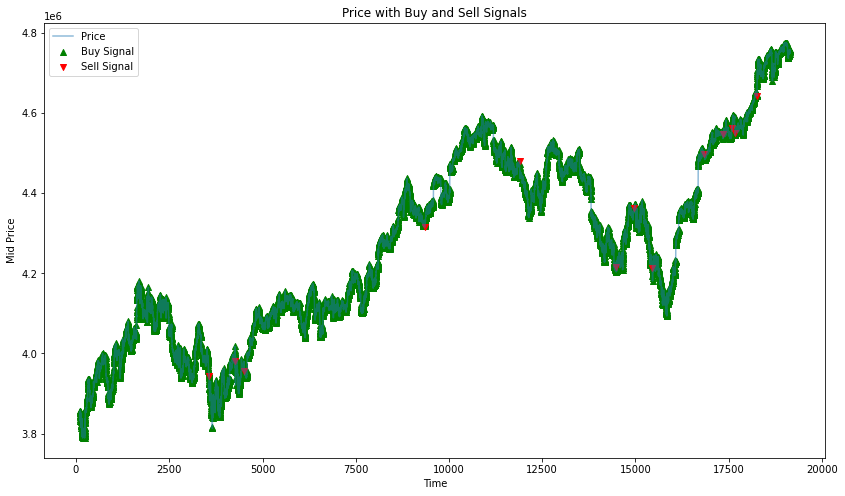

In [38]:
# import matplotlib.pyplot as plt


# buy_signals = []
# sell_signals = []
# for i in range(len(y_pred_2023)):
#     if y_pred_2023[i] == 1:  # Buy signal
#         buy_signals.append(data_5min2023['Mid_Price_1_last'].iloc[i])
#         sell_signals.append(np.nan)
#     elif y_pred_2023[i] == -1:  # Sell signal
#         buy_signals.append(np.nan)
#         sell_signals.append(data_5min2023['Mid_Price_1_last'].iloc[i])
#     else:
#         buy_signals.append(np.nan)
#         sell_signals.append(np.nan)

# # Plot the price with buy and sell signals
# plt.figure(figsize=(14, 8))
# plt.plot(data_5min2023['Mid_Price_1_last'], label='Price', alpha=0.5)
# plt.scatter(data_5min2023.index, buy_signals, label='Buy Signal', marker='^', color='g', alpha=1)
# plt.scatter(data_5min2023.index, sell_signals, label='Sell Signal', marker='v', color='r', alpha=1)
# plt.title('Price with Buy and Sell Signals')
# plt.xlabel('Time')
# plt.ylabel('Mid Price')
# plt.legend(loc='best')
# plt.show()


transaction cost

In [24]:
import joblib
import numpy as np


best_model = joblib.load('best_rf_model_3_to_4.pkl')


y_pred_2023 = best_model.predict(X_test_2023)

#10,000
initial_capital = 10000
capital = initial_capital


transaction_cost_rate = 0.001



shares_held = 0
buy_price = 0  
trade_history = []

for i in range(len(y_pred_2023)):
    if y_pred_2023[i] == 1:  
        if shares_held == 0:  
            shares_held = capital / data_5min2023['Mid_Price_1_last'].iloc[i]
            buy_price = data_5min2023['Mid_Price_1_last'].iloc[i]
            
            capital = capital - (capital * transaction_cost_rate)
            trade_history.append(f"Bought at {buy_price}, shares held: {shares_held}, capital after transaction cost: {capital}")
    
    elif y_pred_2023[i] == -1 and shares_held > 0:  
        sell_price = data_5min2023['Mid_Price_1_last'].iloc[i]
        capital = shares_held * sell_price
        capital = capital - (capital * transaction_cost_rate)
        shares_held = 0
        trade_history.append(f"Sold at {sell_price}, capital after transaction cost: {capital}")


if shares_held > 0:
    final_price = data_5min2023['Mid_Price_1_last'].iloc[-1]
    capital = shares_held * final_price
    capital = capital - (capital * transaction_cost_rate)
    trade_history.append(f"Final sell at {final_price}, final capital: {capital}")


profit_loss = capital - initial_capital
print(f"Final Capital: {capital}")
print(f"Profit/Loss from the strategy after transaction costs: {profit_loss}")

for trade in trade_history:
    print(trade)


Final Capital: 12257.492258913247
Profit/Loss from the strategy after transaction costs: 2257.4922589132475
Bought at 3832900.0, shares held: 0.0026089905815440007, capital after transaction cost: 9990.0
Sold at 3944050.0, capital after transaction cost: 10279.699313835477
Bought at 3946000.0, shares held: 0.002605093591950197, capital after transaction cost: 10269.419614521641
Sold at 3980200.0, capital after transaction cost: 10358.424721165493
Bought at 3987200.0, shares held: 0.002597919522764219, capital after transaction cost: 10348.066296444327
Sold at 3955950.0, capital after transaction cost: 10266.962496343032
Bought at 3957350.0, shares held: 0.0025944034508807745, capital after transaction cost: 10256.695533846689
Sold at 4314050.0, capital after transaction cost: 11181.193821064933
Bought at 4326950.0, shares held: 0.002584082048802259, capital after transaction cost: 11170.012627243868
Sold at 4480850.0, capital after transaction cost: 11567.305164327225
Bought at 4463350

In [25]:
import joblib
import numpy as np

best_model = joblib.load('best_rf_model_3_to_4.pkl')

y_pred_2023 = best_model.predict(X_test_2023)

initial_capital = 10000
capital = initial_capital

transaction_cost_rate = 0.001

returns = []
trade_history = []

shares_held = 0
buy_price = 0 

for i in range(len(y_pred_2023)):
    if y_pred_2023[i] == 1:  
        if shares_held == 0: 
            shares_held = capital / data_5min2023['Mid_Price_1_last'].iloc[i]
            buy_price = data_5min2023['Mid_Price_1_last'].iloc[i]
            capital = capital - (capital * transaction_cost_rate)
            trade_history.append(f"Bought at {buy_price}, shares held: {shares_held}, capital after transaction cost: {capital}")
    
    elif y_pred_2023[i] == -1 and shares_held > 0:  
        sell_price = data_5min2023['Mid_Price_1_last'].iloc[i]
        capital = shares_held * sell_price
        capital = capital - (capital * transaction_cost_rate)
        shares_held = 0
        trade_history.append(f"Sold at {sell_price}, capital after transaction cost: {capital}")
        
        trade_return = (sell_price - buy_price) / buy_price
        returns.append(trade_return)

if shares_held > 0:
    final_price = data_5min2023['Mid_Price_1_last'].iloc[-1]
    capital = shares_held * final_price
    capital = capital - (capital * transaction_cost_rate)
    trade_history.append(f"Final sell at {final_price}, final capital: {capital}")

    final_return = (final_price - buy_price) / buy_price
    returns.append(final_return)

profit_loss = capital - initial_capital
print(f"Final Capital: {capital}")
print(f"Profit/Loss from the strategy after transaction costs: {profit_loss}")


risk_free_rate = 0.01 
excess_returns = np.array(returns) - risk_free_rate
sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns)
print(f"Sharpe Ratio: {sharpe_ratio}")

for trade in trade_history:
    print(trade)


Final Capital: 12257.492258913247
Profit/Loss from the strategy after transaction costs: 2257.4922589132475
Sharpe Ratio: 0.1742974995524641
Bought at 3832900.0, shares held: 0.0026089905815440007, capital after transaction cost: 9990.0
Sold at 3944050.0, capital after transaction cost: 10279.699313835477
Bought at 3946000.0, shares held: 0.002605093591950197, capital after transaction cost: 10269.419614521641
Sold at 3980200.0, capital after transaction cost: 10358.424721165493
Bought at 3987200.0, shares held: 0.002597919522764219, capital after transaction cost: 10348.066296444327
Sold at 3955950.0, capital after transaction cost: 10266.962496343032
Bought at 3957350.0, shares held: 0.0025944034508807745, capital after transaction cost: 10256.695533846689
Sold at 4314050.0, capital after transaction cost: 11181.193821064933
Bought at 4326950.0, shares held: 0.002584082048802259, capital after transaction cost: 11170.012627243868
Sold at 4480850.0, capital after transaction cost: 115

In [26]:
# Simulate a buy-and-hold strategy for 2023

initial_capital = 10000


buy_price_bh = data_5min2023['Mid_Price_1_last'].iloc[0] 
final_price_bh = data_5min2023['Mid_Price_1_last'].iloc[-1] 

shares_held_bh = initial_capital / buy_price_bh

final_capital_bh = shares_held_bh * final_price_bh

profit_loss_bh = final_capital_bh - initial_capital

print(f"Buy-and-Hold Final Capital: {final_capital_bh}")
print(f"Buy-and-Hold Profit/Loss: {profit_loss_bh}")


Buy-and-Hold Final Capital: 12400.532234078635
Buy-and-Hold Profit/Loss: 2400.532234078635


In [28]:
buy_price_bh = data_5min2023['Mid_Price_1_last'].iloc[0]
final_price_bh = data_5min2023['Mid_Price_1_last'].iloc[-1]
shares_held_bh = initial_capital / buy_price_bh
final_capital_bh = shares_held_bh * final_price_bh
profit_loss_bh = final_capital_bh - initial_capital

print(f"Buy-and-Hold Final Capital: {final_capital_bh}")
print(f"Buy-and-Hold Profit/Loss: {profit_loss_bh}")
print(f"Active Trading Final Capital: {capital}")
print(f"Active Trading Profit/Loss after transaction costs: {profit_loss}")
print(f"Sharpe Ratio of Active Trading Strategy: {sharpe_ratio}")


Buy-and-Hold Final Capital: 12400.532234078635
Buy-and-Hold Profit/Loss: 2400.532234078635
Active Trading Final Capital: 12257.492258913247
Active Trading Profit/Loss after transaction costs: 2257.4922589132475
Sharpe Ratio of Active Trading Strategy: 0.1742974995524641


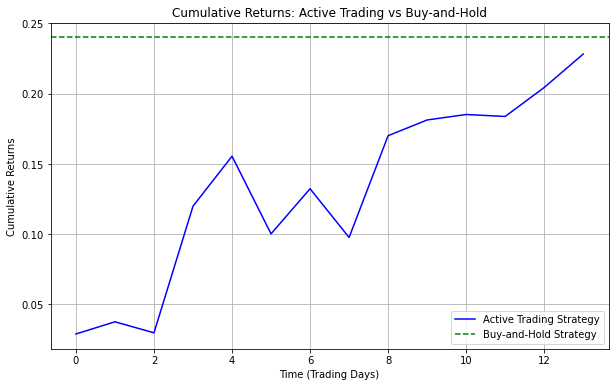

In [29]:
import matplotlib.pyplot as plt
import numpy as np

cumulative_returns_active = np.cumsum(returns)

initial_price_bh = data_5min2023['Mid_Price_1_last'].iloc[0]
final_price_bh = data_5min2023['Mid_Price_1_last'].iloc[-1]
cumulative_returns_bh = (final_price_bh / initial_price_bh - 1)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_returns_active, label='Active Trading Strategy', color='blue')
plt.axhline(y=cumulative_returns_bh, color='green', linestyle='--', label='Buy-and-Hold Strategy')
plt.title('Cumulative Returns: Active Trading vs Buy-and-Hold')
plt.xlabel('Time (Trading Days)')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()


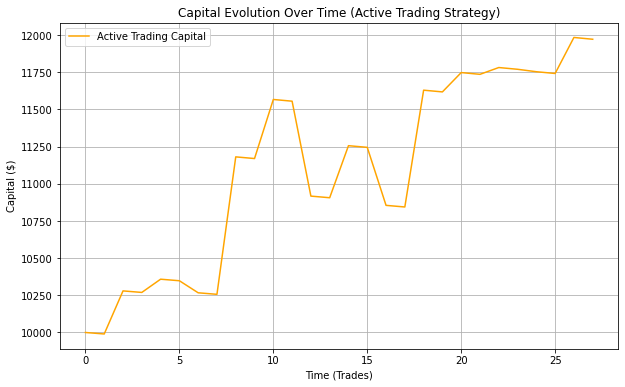

In [31]:
# Track capital over time for active trading
capital_over_time = [initial_capital]  

for i in range(len(trade_history)):
    if 'Bought' in trade_history[i] or 'Sold' in trade_history[i]:
        capital_over_time.append(float(trade_history[i].split('capital after transaction cost: ')[-1]))

plt.figure(figsize=(10, 6))
plt.plot(capital_over_time, label='Active Trading Capital', color='orange')
plt.title('Capital Evolution Over Time (Active Trading Strategy)')
plt.xlabel('Time (Trades)')
plt.ylabel('Capital ($)')
plt.grid(True)
plt.legend()
plt.show()


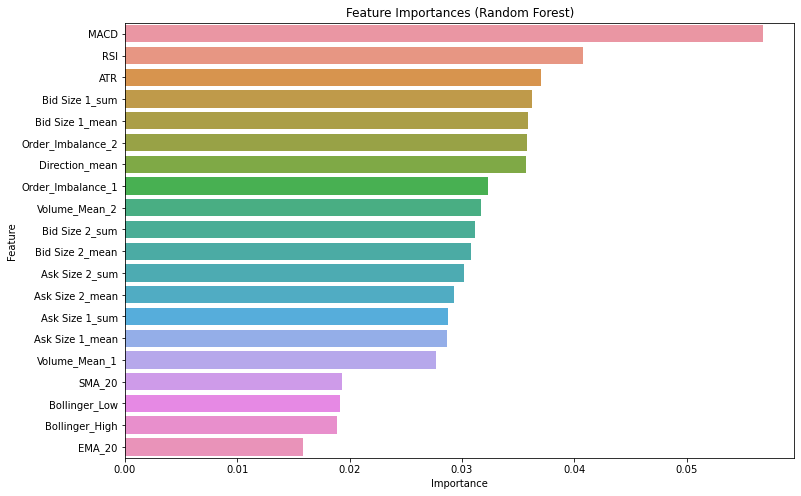

In [34]:
import seaborn as sns

feature_importances = best_model.feature_importances_
feature_names = X_test_2023.columns

importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(20))
plt.title('Feature Importances (Random Forest)')
plt.show()


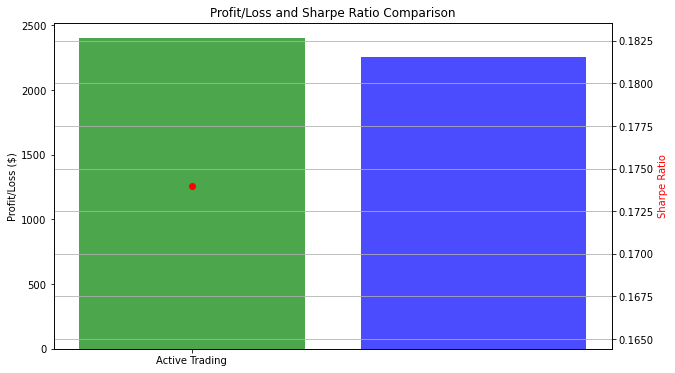

In [35]:
strategy_names = ['Buy-and-Hold', 'Active Trading']
profits = [2400.53, 2257.49] 
sharpe_ratios = [None, 0.174]  

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(strategy_names, profits, color=['green', 'blue'], alpha=0.7)
ax1.set_ylabel('Profit/Loss ($)', color='black')
ax1.set_title('Profit/Loss and Sharpe Ratio Comparison')


ax2 = ax1.twinx()
ax2.plot(strategy_names[1:], sharpe_ratios[1:], color='red', marker='o', label='Sharpe Ratio')
ax2.set_ylabel('Sharpe Ratio', color='red')

plt.grid(True)
plt.show()


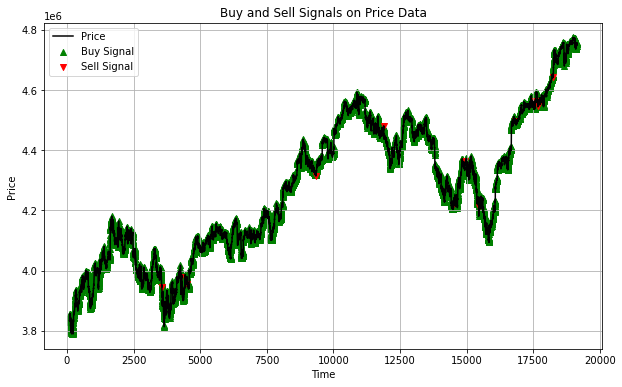

In [36]:

buy_signals = data_5min2023[y_pred_2023 == 1]['Mid_Price_1_last']
sell_signals = data_5min2023[y_pred_2023 == -1]['Mid_Price_1_last']

plt.figure(figsize=(10, 6))
plt.plot(data_5min2023['Mid_Price_1_last'], label='Price', color='black')
plt.scatter(buy_signals.index, buy_signals, marker='^', color='green', label='Buy Signal', alpha=1)
plt.scatter(sell_signals.index, sell_signals, marker='v', color='red', label='Sell Signal', alpha=1)
plt.title('Buy and Sell Signals on Price Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


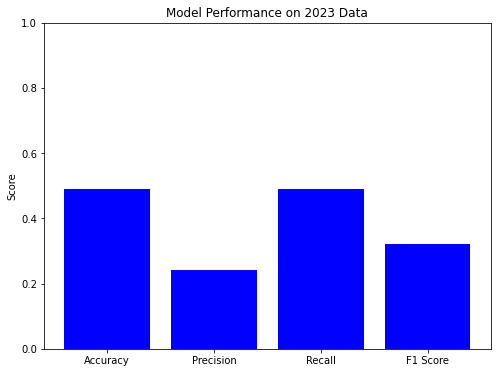

In [37]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy_2023, precision_2023, recall_2023, f1_2023]

plt.figure(figsize=(8, 6))
plt.bar(metrics, scores, color='blue')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance on 2023 Data')
plt.show()
